**Đồ Án Môn Học LBP**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đang nạp dữ liệu huấn luyện...
Đã train xong với 1 ảnh.

===== TRAIN SAMPLES =====


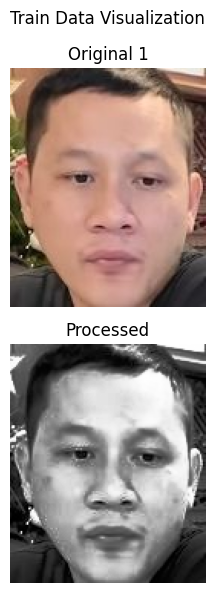

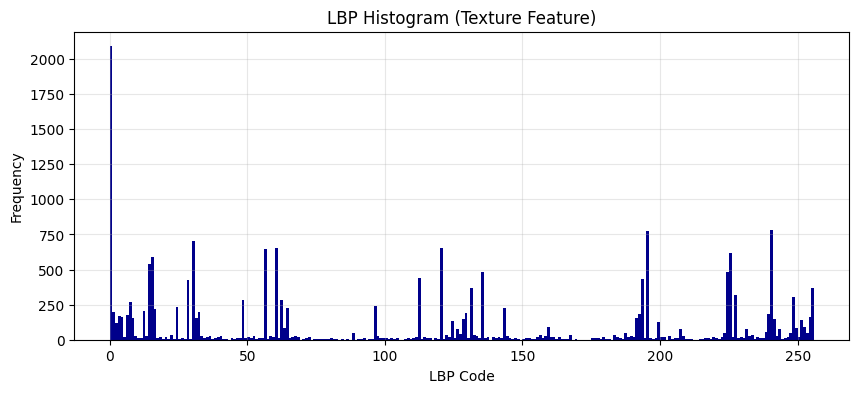


==================== NHÓM NGƯỜI LẠ ====================
image-4.jpg | UNKNOWN | Conf=116.84
image_1.jpg | ME | Conf=0.00
image-5.jpg | UNKNOWN | Conf=99.49
image_6.jpg | ME | Conf=68.31
image-2.jpg | UNKNOWN | Conf=86.27
image_7.jpg | UNKNOWN | Conf=96.34
image-3.jpg | UNKNOWN | Conf=80.18

--- STATISTICS ---
Mean: 78.20
Min : 0.00
Max : 116.84
Std : 34.96


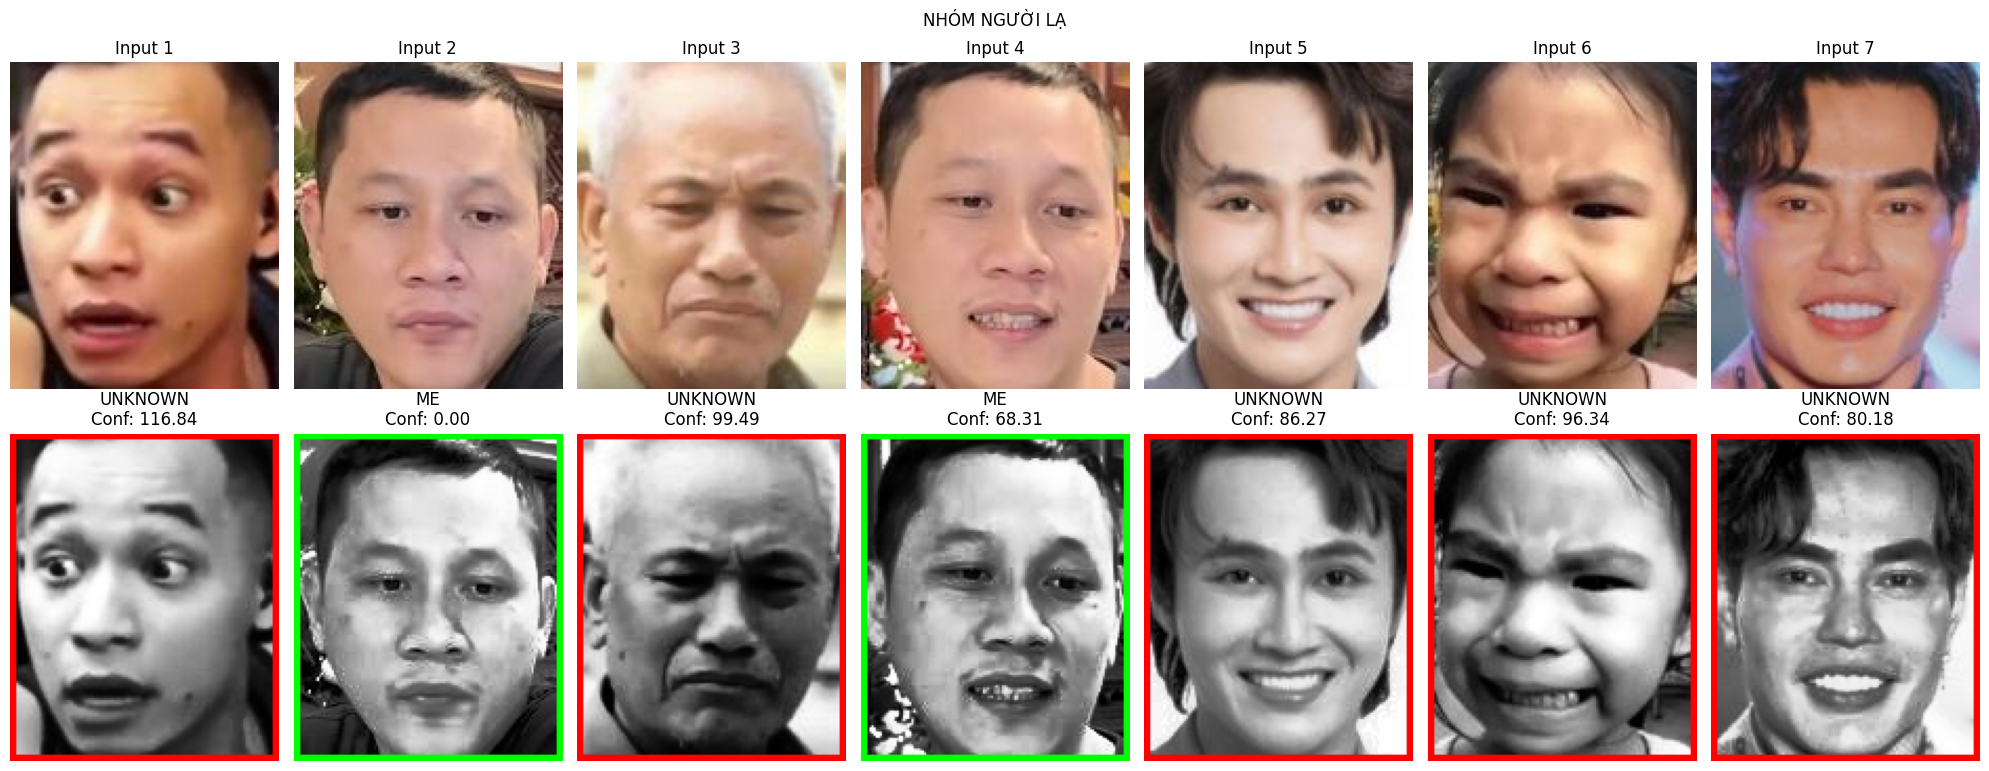

In [ ]:
from google.colab import drive
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Mount Google Drive
# =========================
drive.mount('/content/drive')

# =========================
# 2. Config đường dẫn
# =========================
DATA_PATH = '/content/drive/MyDrive/Đồ_Án_MH'
TRAIN_PATH = os.path.join(DATA_PATH, 'train')
TEST_OTHERS = os.path.join(DATA_PATH, 'others')

IMG_SIZE = (128, 156)  # chỉ để kiểm tra, KHÔNG resize

recognizer = cv2.face.LBPHFaceRecognizer_create(
    radius=1,
    neighbors=8,
    grid_x=8,
    grid_y=8
)

MY_ID = 1
THRESHOLD = 75


# =========================
# 3. PREPROCESS (GIỐNG NHAU)
# =========================
def preprocess(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)  # normalize ánh sáng
    return gray


# =========================
# 4. TRAIN
# =========================
def train_model():
    train_data = []
    labels = []

    print("Đang nạp dữ liệu huấn luyện...")

    for filename in os.listdir(TRAIN_PATH):
        path = os.path.join(TRAIN_PATH, filename)
        img_bgr = cv2.imread(path)

        if img_bgr is None:
            continue

        # kiểm tra size (optional)
        if img_bgr.shape[1] != IMG_SIZE[0] or img_bgr.shape[0] != IMG_SIZE[1]:
            print(f"[WARNING] {filename} không đúng size!")

        img_processed = preprocess(img_bgr)

        train_data.append(img_processed)
        labels.append(MY_ID)

    recognizer.train(train_data, np.array(labels))
    print(f"Đã train xong với {len(train_data)} ảnh.")


# =========================
# 5. LBP FEATURE (để visualize)
# =========================
def compute_lbp(img):
    h, w = img.shape
    lbp = np.zeros((h, w), dtype=np.uint8)

    for i in range(1, h-1):
        for j in range(1, w-1):
            c = img[i, j]
            code = 0
            code |= (img[i-1,j-1] > c) << 7
            code |= (img[i-1,j]   > c) << 6
            code |= (img[i-1,j+1] > c) << 5
            code |= (img[i,j+1]   > c) << 4
            code |= (img[i+1,j+1] > c) << 3
            code |= (img[i+1,j]   > c) << 2
            code |= (img[i+1,j-1] > c) << 1
            code |= (img[i,j-1]   > c) << 0
            lbp[i,j] = code

    return lbp


def show_lbp_histogram(sample_img):
    lbp = compute_lbp(sample_img)

    plt.figure(figsize=(10,4))
    plt.hist(lbp.ravel(), bins=256, range=(0,256), color='darkblue')
    plt.title("LBP Histogram (Texture Feature)")
    plt.xlabel("LBP Code")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()


# =========================
# 6. TEST + VISUALIZE
# =========================
def test_and_visualize(folder_path, title):
    print(f"\n{'='*20} {title} {'='*20}")

    files = [f for f in os.listdir(folder_path)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if not files:
        print("Không có ảnh!")
        return

    num_imgs = min(len(files), 10)
    fig, axes = plt.subplots(2, num_imgs, figsize=(20, 8))

    if num_imgs == 1:
        axes = np.expand_dims(axes, axis=1)

    confidences = []

    for i in range(num_imgs):
        path = os.path.join(folder_path, files[i])
        img_bgr = cv2.imread(path)

        if img_bgr is None:
            continue

        img_processed = preprocess(img_bgr)

        # predict
        id_pred, conf = recognizer.predict(img_processed)
        confidences.append(conf)

        is_me = (id_pred == MY_ID and conf < THRESHOLD)
        label = "ME" if is_me else "UNKNOWN"
        color = (0, 255, 0) if is_me else (255, 0, 0)

        # show original
        axes[0, i].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        axes[0, i].set_title(f"Input {i+1}")
        axes[0, i].axis("off")

        # show processed
        img_show = cv2.cvtColor(img_processed, cv2.COLOR_GRAY2RGB)
        cv2.rectangle(
            img_show,
            (0, 0),
            (img_show.shape[1]-1, img_show.shape[0]-1),
            color, 3
        )

        axes[1, i].imshow(img_show)
        axes[1, i].set_title(f"{label}\nConf: {conf:.2f}")
        axes[1, i].axis("off")

        print(f"{files[i]} | {label} | Conf={conf:.2f}")

    confidences = np.array(confidences)

    print("\n--- STATISTICS ---")
    print(f"Mean: {confidences.mean():.2f}")
    print(f"Min : {confidences.min():.2f}")
    print(f"Max : {confidences.max():.2f}")
    print(f"Std : {confidences.std():.2f}")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
def show_train_samples(num_samples=10):
    print("\n===== TRAIN SAMPLES =====")

    files = [f for f in os.listdir(TRAIN_PATH)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if not files:
        print("Không có ảnh train!")
        return

    num_samples = min(num_samples, len(files))

    fig, axes = plt.subplots(2, num_samples, figsize=(20, 6))

    if num_samples == 1:
        axes = np.expand_dims(axes, axis=1)

    for i in range(num_samples):
        path = os.path.join(TRAIN_PATH, files[i])
        img_bgr = cv2.imread(path)

        if img_bgr is None:
            continue

        img_processed = preprocess(img_bgr)

        # ảnh gốc
        axes[0, i].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        axes[0, i].set_title(f"Original {i+1}")
        axes[0, i].axis("off")

        # ảnh sau preprocess
        axes[1, i].imshow(img_processed, cmap='gray')
        axes[1, i].set_title("Processed")
        axes[1, i].axis("off")

    plt.suptitle("Train Data Visualization")
    plt.tight_layout()
    plt.show()

# =========================
# ▶️ RUN
# =========================
train_model()
show_train_samples()

# xem histogram 1 ảnh train
sample_path = os.path.join(TRAIN_PATH, os.listdir(TRAIN_PATH)[0])
sample_img = preprocess(cv2.imread(sample_path))
show_lbp_histogram(sample_img)

# test
test_and_visualize(TEST_OTHERS, "NHÓM NGƯỜI LẠ")